<a href="https://colab.research.google.com/github/bungalunnac/Pembelajaran_mesin/blob/main/UAS/uas_pm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [3]:
df = pd.read_csv('/content/Titanic-Dataset.csv')  # sesuaikan nama file CSV kamu
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("=== INFO DATASET ===")
print(df.info())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== MISSING VALUES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


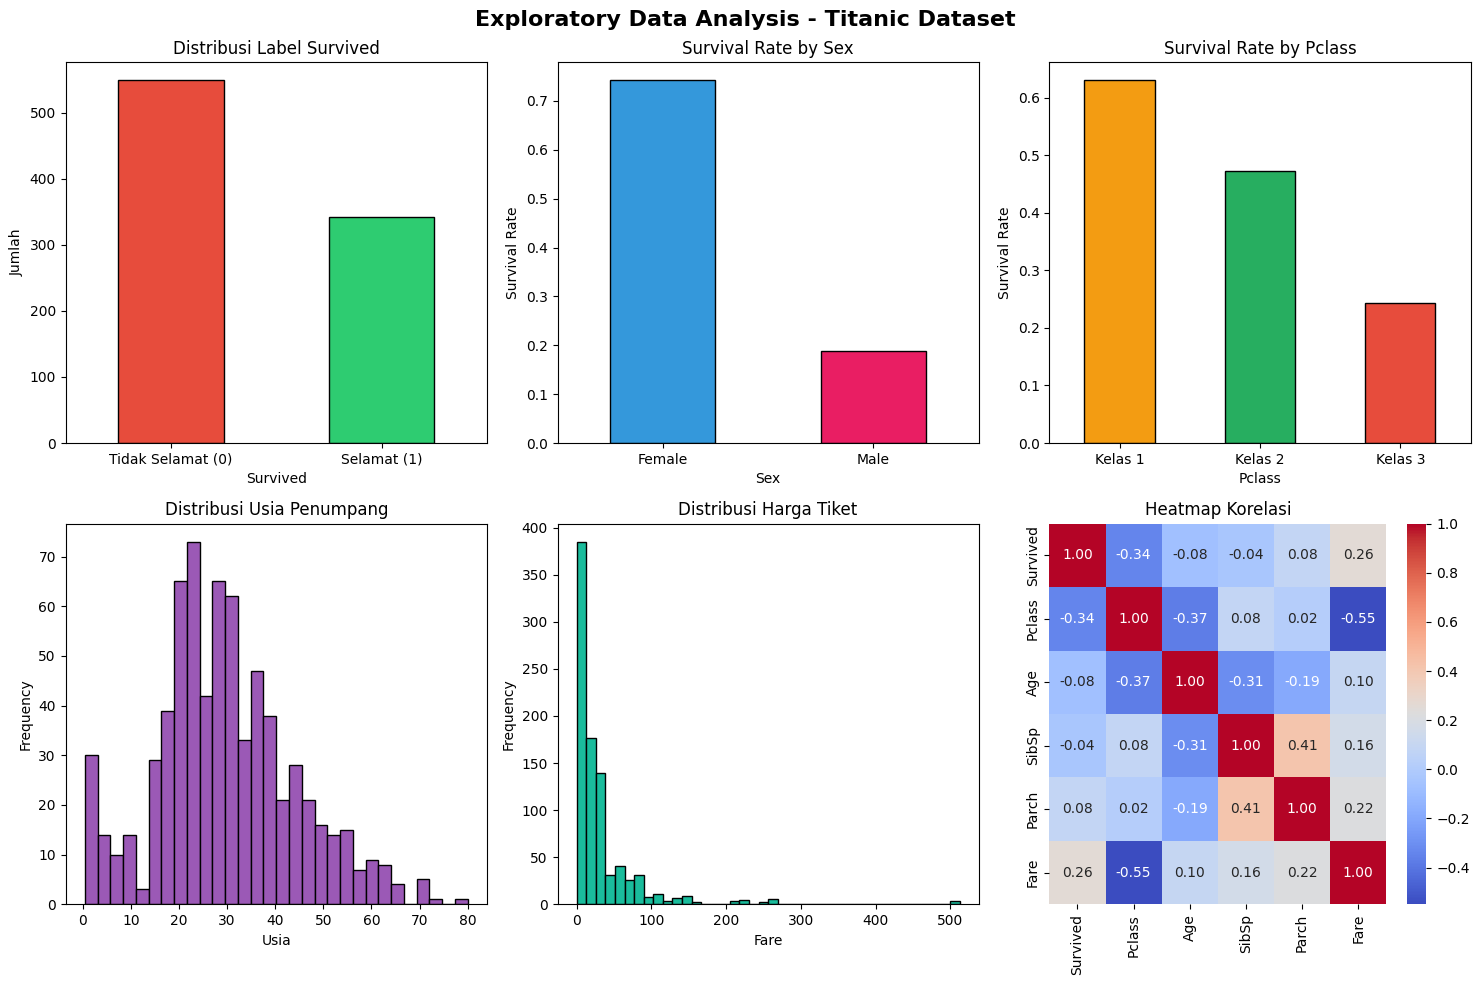

✅ Visualisasi selesai!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Titanic Dataset', fontsize=16, fontweight='bold')

# 1. Distribusi Survived
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Distribusi Label Survived')
axes[0,0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'], rotation=0)
axes[0,0].set_ylabel('Jumlah')

# 2. Survival rate by Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color=['#3498db','#e91e63'], edgecolor='black')
axes[0,1].set_title('Survival Rate by Sex')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xticklabels(['Female', 'Male'], rotation=0)

# 3. Survival rate by Pclass
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,2], color=['#f39c12','#27ae60','#e74c3c'], edgecolor='black')
axes[0,2].set_title('Survival Rate by Pclass')
axes[0,2].set_ylabel('Survival Rate')
axes[0,2].set_xticklabels(['Kelas 1', 'Kelas 2', 'Kelas 3'], rotation=0)

# 4. Distribusi Age
df['Age'].dropna().plot(kind='hist', ax=axes[1,0], bins=30, color='#9b59b6', edgecolor='black')
axes[1,0].set_title('Distribusi Usia Penumpang')
axes[1,0].set_xlabel('Usia')

# 5. Distribusi Fare
df['Fare'].plot(kind='hist', ax=axes[1,1], bins=40, color='#1abc9c', edgecolor='black')
axes[1,1].set_title('Distribusi Harga Tiket')
axes[1,1].set_xlabel('Fare')

# 6. Heatmap korelasi
corr_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi selesai!")

In [6]:
df_clean = df.copy()

# 1. Hapus kolom tidak relevan
df_clean.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# 2. Handle missing values
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Encoding Sex
df_clean['Sex'] = LabelEncoder().fit_transform(df_clean['Sex'])  # male=1, female=0

# 4. One-Hot Encoding Embarked
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

print("Shape setelah preprocessing:", df_clean.shape)
print("\nMissing values setelah preprocessing:")
print(df_clean.isnull().sum())
df_clean.head()

Shape setelah preprocessing: (891, 9)

Missing values setelah preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [7]:
# Tambah fitur baru
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print("Fitur setelah feature engineering:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)
df_clean.head()

Fitur setelah feature engineering: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']
Shape: (891, 11)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1


In [8]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# Split 80:20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train_scaled.shape}")
print(f"Testing set  : {X_test_scaled.shape}")
print(f"\nDistribusi label train:\n{y_train.value_counts()}")
print(f"\nDistribusi label test:\n{y_test.value_counts()}")

Training set : (712, 10)
Testing set  : (179, 10)

Distribusi label train:
Survived
0    439
1    273
Name: count, dtype: int64

Distribusi label test:
Survived
0    110
1     69
Name: count, dtype: int64


In [9]:
# Model 1: Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("✅ Kedua model berhasil ditraining!")

✅ Kedua model berhasil ditraining!


In [10]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    return y_pred

nb_pred = evaluate_model("Gaussian Naive Bayes", nb_model, X_test_scaled, y_test)
rf_pred = evaluate_model("Random Forest",        rf_model, X_test_scaled, y_test)


  Gaussian Naive Bayes
  Accuracy  : 0.7821
  Precision : 0.7143
  Recall    : 0.7246
  F1-Score  : 0.7194
  ROC-AUC   : 0.8076

  Random Forest
  Accuracy  : 0.8212
  Precision : 0.7846
  Recall    : 0.7391
  F1-Score  : 0.7612
  ROC-AUC   : 0.8318


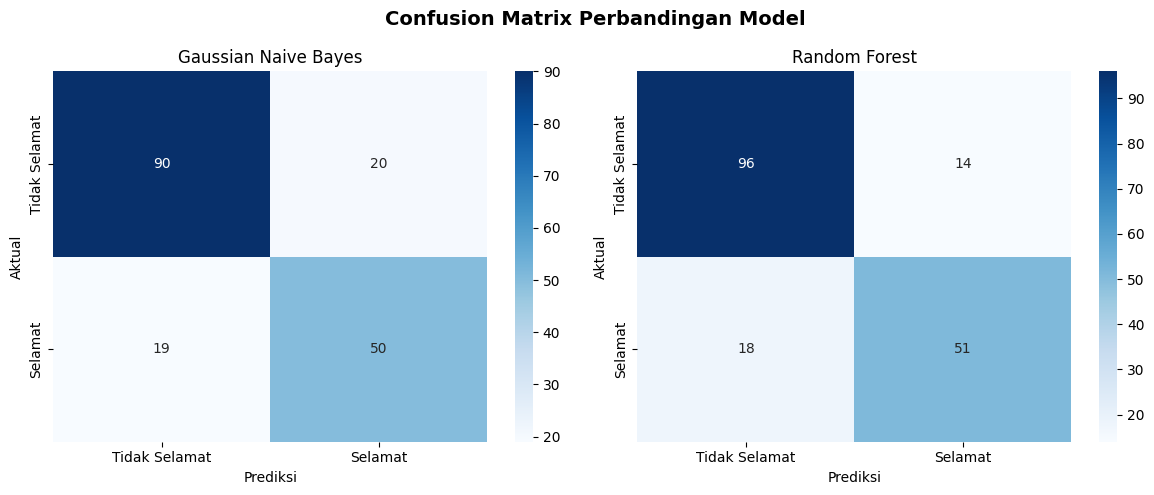

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix Perbandingan Model', fontsize=14, fontweight='bold')

for ax, model, pred, name in zip(
    axes,
    [nb_model, rf_model],
    [nb_pred, rf_pred],
    ["Gaussian Naive Bayes", "Random Forest"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Selamat','Selamat'],
                yticklabels=['Tidak Selamat','Selamat'])
    ax.set_title(name)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

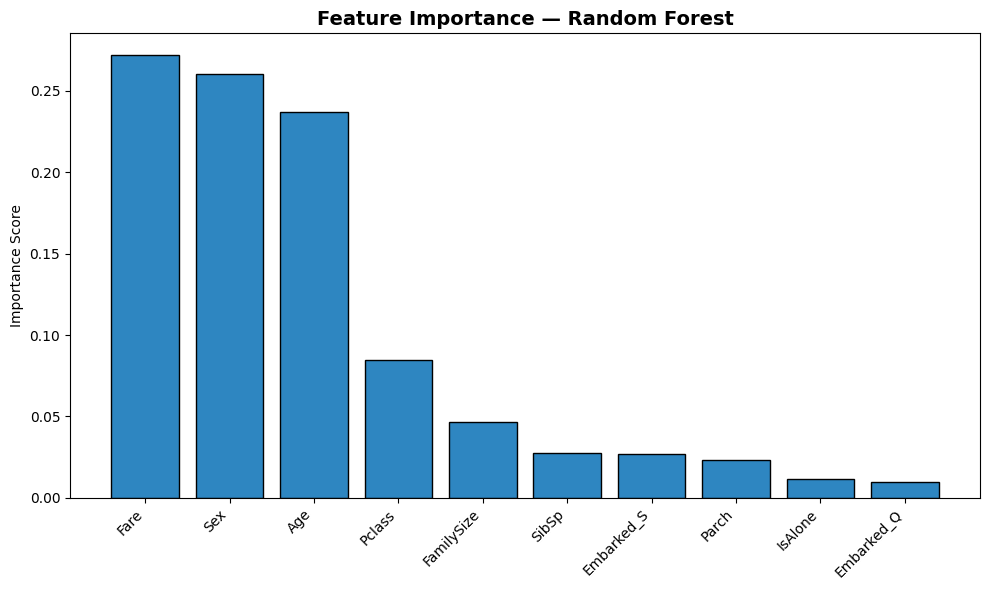


Ranking Feature Importance:
  Fare            : 0.2718
  Sex             : 0.2603
  Age             : 0.2372
  Pclass          : 0.0849
  FamilySize      : 0.0468
  SibSp           : 0.0275
  Embarked_S      : 0.0268
  Parch           : 0.0232
  IsAlone         : 0.0118
  Embarked_Q      : 0.0097


In [12]:
feat_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.bar(range(len(feat_names)), importances[indices], color='#2E86C1', edgecolor='black')
plt.xticks(range(len(feat_names)), [feat_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRanking Feature Importance:")
for i in indices:
    print(f"  {feat_names[i]:<15} : {importances[i]:.4f}")

In [13]:
print("=" * 50)
print("        RINGKASAN HASIL EKSPERIMEN")
print("=" * 50)

models = {
    "Gaussian Naive Bayes": nb_model,
    "Random Forest"       : rf_model,
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
best = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\n🏆 Model terbaik berdasarkan F1-Score: {best}")

        RINGKASAN HASIL EKSPERIMEN
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gaussian Naive Bayes    0.7821     0.7143  0.7246    0.7194   0.8076
       Random Forest    0.8212     0.7846  0.7391    0.7612   0.8318

🏆 Model terbaik berdasarkan F1-Score: Random Forest
